# docTR Setup & Testing

In [ ]:
%pip install python-doctr

In [ ]:
%pip install "python-doctr[viz,html,contrib]"

In [ ]:
%pip install -e doctr/.

d:\Documents\GitHub\CADT\Capstone\Khmer-Data-Annotation-Project\experiment\models\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading OCR model...
Model loaded successfully.
Reading image...
Running OCR...


Processing: 100%|█████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.28it/s]


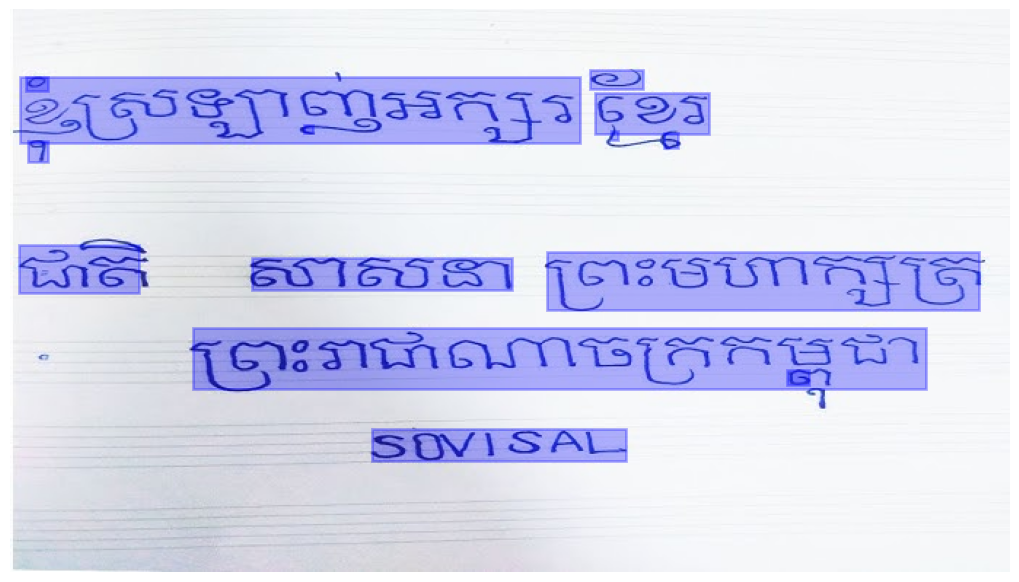


========== OCR EXTRACTED TEXT ==========

ឲៃ|ចដ៩|៩ឿៃឹ
ឲ/ឲ/"៝។_៕ដ៥&ែ។ែ៝ឺ=ៀ៎
ឭែះៀះភះឝះវៀណៀ=ភៀឝ
*(#្#២្ឿ២ឿ៩២ឿ្២្ឌ៩>ខ្្#្&្៕>=្= ២ឰឹ៥្ណះ៌ន៥ៃឭខ:៥ៃ=ៃកៃ៉=
ណៀឈ=ឝវ៥ណៀណឝ
ដឲចដ|ឩ?ឿ=
ច^ក=កឌវណ៉ណឿណៃ=ៃ
ឞ៥្@ឡ=៩២&ឌ=ឌឺឌ
២ឰឿ#ឿ៌ឿ៩>&៙៩ះ&កឿ៩៌&កចឌ៩>២#ឿ#៌ឿ&៕ក&្#្&្៌
ឌឧ៥&៥ឧឌ៥្=ឌ៥៕ឧ=្៥&=>
ឌ=៉២@>៥#្ឧច៥ឌ្ះ&ឧ=្ឹ@ឧ៥ឹឯឌ៥@^@២ឧ៥្៥្ឌ|ឧ៥្៥&ឹ៥្៥ឧ៕៥&៥ឧ&្=
ឲឧៗឞក៌ឰ[ឌ.៏.|ឿ=៩ៃ៩=ៃ=
ច្?៌៍ឧ|៥ឧ)^៍២្៥ឰ?៌ើ៥ឧច៥ឿ

========== PAGE LANGUAGE ==========
Page 1: unknown (confidence=0.000)

Saved:
- ocr_result.json
- ocr_text.txt


In [1]:
from doctr.models import ocr_predictor, crnn_vgg16_bn
from doctr.datasets import VOCABS
from doctr.io import DocumentFile
from tqdm import tqdm
import time
import json

# 1) Build Khmer-aware OCR model
print("Loading OCR model...")
reco_model = crnn_vgg16_bn(pretrained=True, vocab=VOCABS["khmer"])
model = ocr_predictor(
    det_arch="fast_base",
    reco_arch=reco_model,   # use reco_arch, not reco_model
    pretrained=True,
    detect_language=True
)
print("Model loaded successfully.")

# 2) Read image
print("Reading image...")
doc = DocumentFile.from_images("images/demo_hand_written.jpg")

# 3) Progress bar (visual only)
print("Running OCR...")
for _ in tqdm(range(5), desc="Processing", ncols=100):
    time.sleep(0.3)

# 4) Run OCR
result = model(doc)

# 5) Show detected boxes + text overlay
result.show()

# 6) Export OCR structure
ocr_data = result.export()

# Save structured result
with open("ocr_result.json", "w", encoding="utf-8") as f:
    json.dump(ocr_data, f, indent=2, ensure_ascii=False)

# 7) Extract plain text
all_pages_text = []
for page in ocr_data["pages"]:
    page_lines = []
    for block in page["blocks"]:
        for line in block["lines"]:
            line_text = " ".join(word["value"] for word in line["words"])
            page_lines.append(line_text)
    all_pages_text.append("\n".join(page_lines))

full_text = "\n\n--- PAGE BREAK ---\n\n".join(all_pages_text)

# Save plain text
with open("ocr_text.txt", "w", encoding="utf-8") as f:
    f.write(full_text)

# 8) Output everything at once
print("\n========== OCR EXTRACTED TEXT ==========\n")
print(full_text if full_text.strip() else "[No text recognized]")

# Optional language output (if available)
print("\n========== PAGE LANGUAGE ==========")
for i, page in enumerate(ocr_data["pages"], start=1):
    lang = page.get("language")
    if lang:
        print(f"Page {i}: {lang.get('value')} (confidence={lang.get('confidence'):.3f})")
    else:
        print(f"Page {i}: [No language prediction]")

print("\nSaved:")
print("- ocr_result.json")
print("- ocr_text.txt")
